### Step 0: Select a Company
I selected **Toronto-Dominion Bank (Ticker: TD)** from **Group 2 (Canada)**, as assigned by the last digit of my Student ID (which ends in 2). 

**Reason for selection:** I chose TD because it demonstrated remarkable resilience as a 'Safe Giant' in Homework 1, completely ignoring the geopolitical tensions of the Strait of Hormuz. I now want to deep-dive into its fundamentals to understand the actual financial strength and profitability behind that market resilience.

In [1]:
# STEP 0: SELECTION VARIABLES

# Let’s set the variables we’ll need for all the subsequent steps

my_symbol = 'TD'
my_assigned_country = 'Canada'

print(f"Step 0 Completed: Selected {my_symbol} from the group {my_assigned_country}.")

Step 0 Completed: Selected TD from the group Canada.


### Step 1

In [2]:
import pandas as pd
import numpy as np

# ==========================================
# STEP 1: DATA PREPARATION & DATA QUALITY (ETL Phase)
# ==========================================

# 1. EXTRACTION: Loading the raw dataset
df = pd.read_csv('Symbol_Info_extended.csv')

# 2. TRANSFORMATION: Selecting only the required columns for our Data Mart
cols_to_keep = [
    'symbol', 'company_name', 'sector', 'industry', 'country', 'market_cap',
    'return_on_assets', 'return_on_equity', 'profit_margins',
    'pe_trailing', 'price_to_book', 'revenue_growth', 'debt_to_equity', 'free_cashflow'
]
df_clean = df[cols_to_keep].copy()

# 3. CLEANSING: Applying mandatory rules to ensure Data Quality
# Replacing infinite values with NaN (handling missing/corrupted data)
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

# Filtering out companies with non-positive market cap (logical constraint)
df_clean = df_clean[df_clean['market_cap'] > 0]

# Removing nonsensical valuation metrics (P/E and P/B must be strictly > 0)
df_clean.loc[df_clean['pe_trailing'] <= 0, 'pe_trailing'] = np.nan
df_clean.loc[df_clean['price_to_book'] <= 0, 'price_to_book'] = np.nan

print(f"Step 1 Complete: Dataset uploaded and cleaned. Current dimensions: {df_clean.shape}")

Step 1 Complete: Dataset uploaded and cleaned. Current dimensions: (2970, 14)


### Step 2

In [3]:
# ==========================================
# STEP 2: BUILD PEER GROUPS
# ==========================================

# RIGA AGGIUNTA (RISOLUZIONE ERRORE): Estraiamo dal dataset pulito l'intera riga della nostra azienda (TD)
my_company_data = df_clean[df_clean['symbol'] == my_symbol].iloc[0]

# Retrieving the industry of our target company (TD is in 'Banks - Diversified' or similar)
my_industry = my_company_data['industry']

# --- GROUP A: Same Industry Peers ---
# Rationale: We filter companies in the same industry and select the top 10 by Market Cap 
# to compare our company against the main industry leaders.
group_a_all = df_clean[df_clean['industry'] == my_industry].sort_values(by='market_cap', ascending=False)
group_a = group_a_all.head(10).copy()

# Critical check: if our target company is not in the top 10, we append it to ensure it is included in the analysis
if my_symbol not in group_a['symbol'].values:
    group_a = pd.concat([group_a, df_clean[df_clean['symbol'] == my_symbol]])


# --- GROUP B: Geographic Peers (Canada) ---
# Rationale: Since the Student ID ends in 2, the assigned geographic group is Canada.
# We select the top 10 Canadian companies by Market Cap to evaluate domestic market dynamics.
my_countries = ['Canada'] 
group_b_all = df_clean[df_clean['country'].isin(my_countries)].sort_values(by='market_cap', ascending=False)
group_b = group_b_all.head(10).copy()

# Critical check: if our target company is not in the top 10, we append it
if my_symbol not in group_b['symbol'].values:
    group_b = pd.concat([group_b, df_clean[df_clean['symbol'] == my_symbol]])


# --- GROUP C: Closest Market Capitalization Peers ---
# Rationale: We calculate the absolute distance in Market Cap between TD and all other companies.
# This allows us to find peer companies of the exact same size, regardless of their sector or country.
df_clean['mcap_distance'] = abs(df_clean['market_cap'] - my_company_data['market_cap'])
group_c_all = df_clean.sort_values(by='mcap_distance')

# We select the top 10 closest companies (this automatically includes TD as its distance to itself is 0)
group_c = group_c_all.head(10).copy()



print(f"Target Company: {my_company_data['company_name']} ({my_symbol})\n")

print(f" PREVIEW VIEW OF GROUPS:")

print(f"\n1. GROUP A (Same Industry: {my_industry}) - Top 5 companies:")
display(group_a[['symbol', 'company_name', 'market_cap', 'country']].head(5))

print(f"\n2. GROUP B (Same Geography: Canada) - Top 5 companies:")
display(group_b[['symbol', 'company_name', 'market_cap', 'industry']].head(5))

print(f"\n3. GROUP C (Same size / Market Cap) - Top 5 companies closest to {my_symbol}:")
display(group_c[['symbol', 'company_name', 'market_cap', 'industry', 'mcap_distance']].head(5))

Target Company: The Toronto-Dominion Bank (TD)

 PREVIEW VIEW OF GROUPS:

1. GROUP A (Same Industry: Banks - Diversified) - Top 5 companies:


,symbol,company_name,market_cap,country
1501,JPM,JPMorgan Chase & Co.,8.209487e+11,United States
306,BAC,Bank of America Corporation,3.676034e+11,United States
2389,RY,Royal Bank of Canada,2.637949e+11,Canada
2959,WFC,Wells Fargo & Company,2.337985e+11,United States
478,C,Citigroup Inc.,2.133506e+11,United States



2. GROUP B (Same Geography: Canada) - Top 5 companies:


,symbol,company_name,market_cap,industry
2389,RY,Royal Bank of Canada,2.637949e+11,Banks - Diversified
2656,TD,The Toronto-Dominion Bank,1.875736e+11,Banks - Diversified
2473,SHOP,Shopify Inc.,1.336584e+11,Software - Application
918,ENB,Enbridge Inc.,1.267417e+11,Oil & Gas Midstream
408,BMO,Bank of Montreal,1.134428e+11,Banks - Diversified



3. GROUP C (Same size / Market Cap) - Top 5 companies closest to TD:


,symbol,company_name,market_cap,industry,mcap_distance
2656,TD,The Toronto-Dominion Bank,1.875736e+11,Banks - Diversified,0.000000e+00
1886,NEE,"NextEra Energy, Inc.",1.846804e+11,Utilities - Regulated Electric,2.893267e+09
803,DELL,Dell Technologies Inc.,1.917460e+11,Computer Hardware,4.172415e+09
149,AMGN,Amgen Inc.,1.831230e+11,Drug Manufacturers - General,4.450615e+09
2609,STX,Seagate Technology Holdings plc,1.822376e+11,Computer Hardware,5.336007e+09


### Step 3: Profitability Analysis
In this section, we analyze the profitability of **Toronto-Dominion Bank (TD)** against its peers in Group A (Industry) and Group B (Geography). 

**Metrics Selected:**
1. **Return on Assets (ROA):** To understand how efficiently the bank uses its massive asset base to generate profit.
2. **Return on Equity (ROE):** Crucial for the banking sector, it shows how effectively the company is using shareholders' equity.


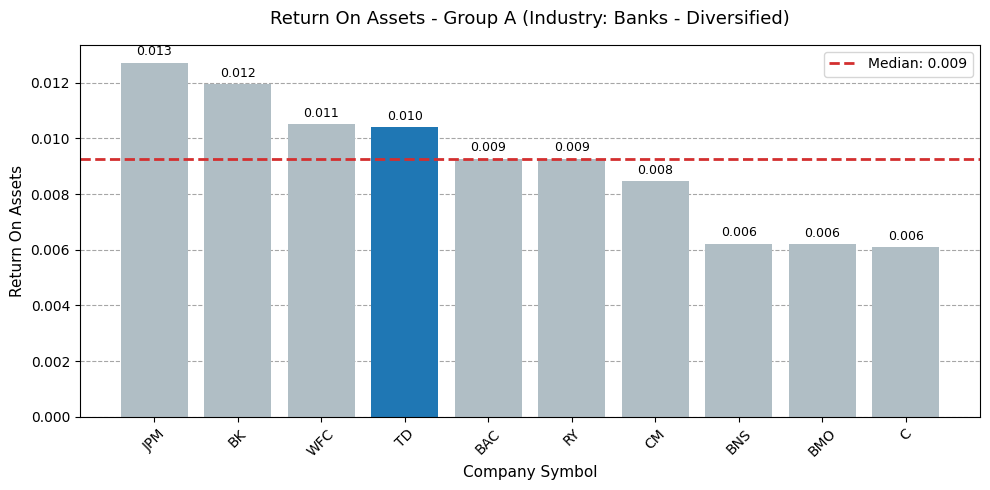

MEDIAN COMPARISON - Group A (Industry: Banks - Diversified):
   -> TD Return On Assets: 0.010
   -> Peer Median: 0.009
   -> Esito: TD is located above the median of the group.

--------------------------------------------------------------------------------


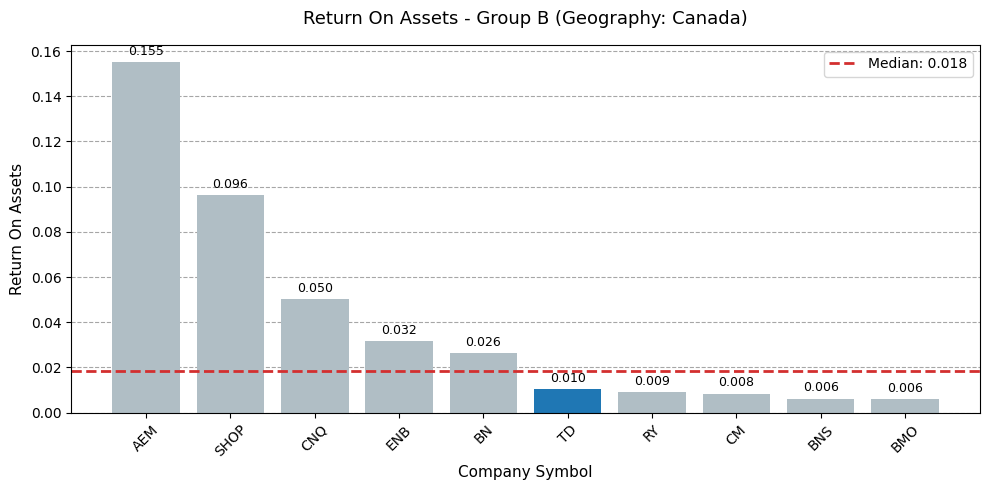

MEDIAN COMPARISON - Group B (Geography: Canada):
   -> TD Return On Assets: 0.010
   -> Peer Median: 0.018
   -> Esito: TD is located below the median of the group.

--------------------------------------------------------------------------------


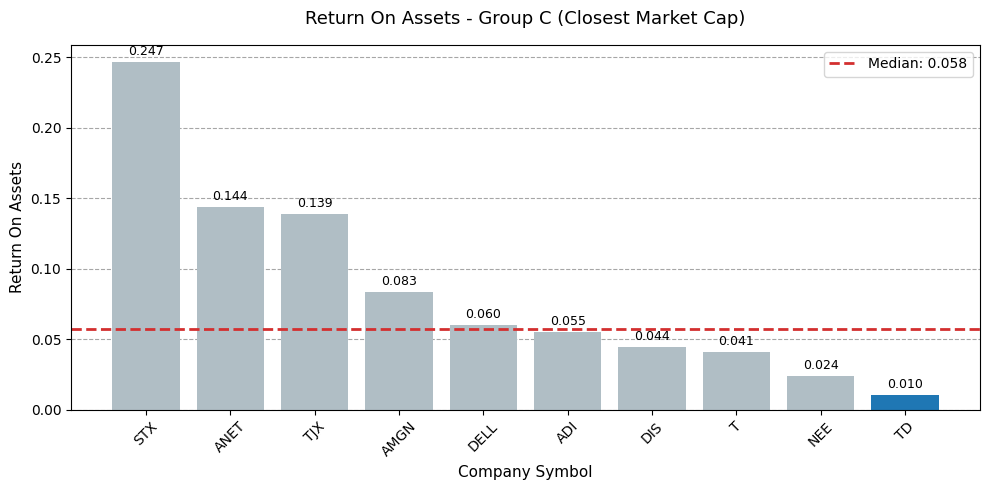

MEDIAN COMPARISON - Group C (Closest Market Cap):
   -> TD Return On Assets: 0.010
   -> Peer Median: 0.058
   -> Esito: TD is located below the median of the group.

--------------------------------------------------------------------------------


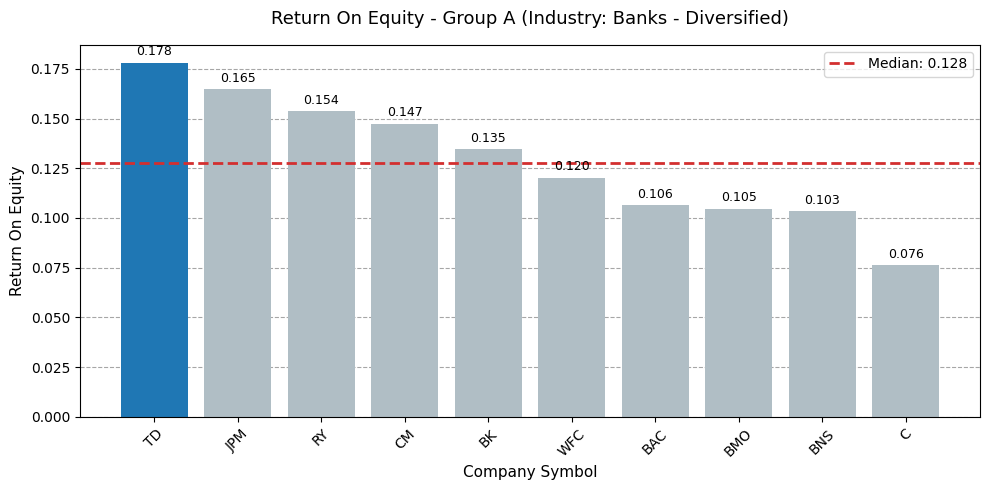

MEDIAN COMPARISON - Group A (Industry: Banks - Diversified):
   -> TD Return On Equity: 0.178
   -> Peer Median: 0.128
   -> Esito: TD is located above the median of the group.

--------------------------------------------------------------------------------


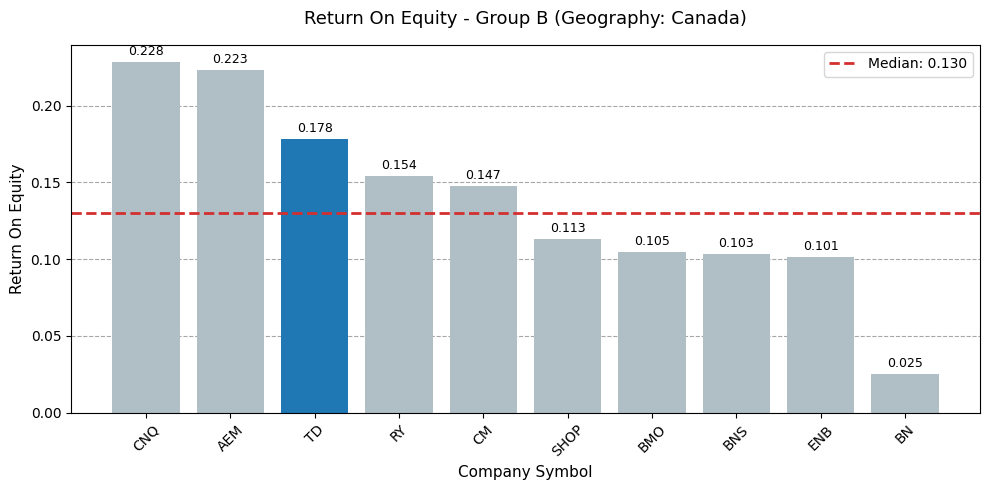

MEDIAN COMPARISON - Group B (Geography: Canada):
   -> TD Return On Equity: 0.178
   -> Peer Median: 0.130
   -> Esito: TD is located above the median of the group.

--------------------------------------------------------------------------------


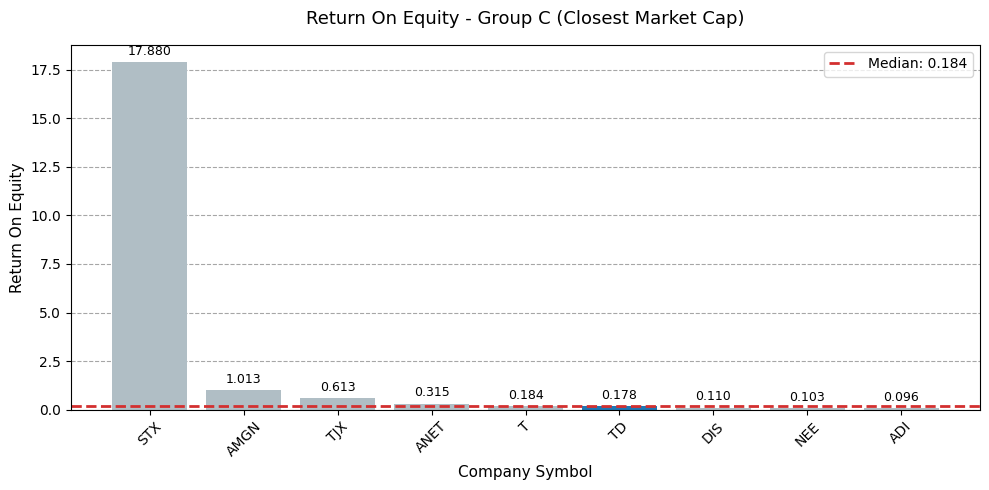

MEDIAN COMPARISON - Group C (Closest Market Cap):
   -> TD Return On Equity: 0.178
   -> Peer Median: 0.184
   -> Esito: TD is located below the median of the group.

--------------------------------------------------------------------------------


In [4]:

import matplotlib.pyplot as plt


def plot_profitability_with_median(group_df, metric_name, group_title, target_symbol):
    
    """
    Create a bar chart, calculate the median and handle missing values for the specified metric.
    """
    
    # 1. To delete missing values ONLY in the metric where it is a null value
    plot_df = group_df.dropna(subset=[metric_name]).copy()
    
    if target_symbol not in plot_df['symbol'].values:
        print(f"{target_symbol} has no valid data for '{metric_name}' in {group_title}.")
        return
    
    # 2. CALCULATING THE MEDIAN AND POSITION
    group_median = plot_df[metric_name].median()
    target_value = plot_df[plot_df['symbol'] == target_symbol][metric_name].values[0]
    position_text = "above" if target_value >= group_median else "below"
    
    # 3. Descending order
    plot_df = plot_df.sort_values(by=metric_name, ascending=False)
    
    # 4. COLOURS (Blue for TD, Grey for the others)
    my_colors = ['#1f77b4' if sym == target_symbol else '#B0BEC5' for sym in plot_df['symbol']]
    
    # 5. CREATING THE CHART
    plt.figure(figsize=(10, 5))
    ax = plt.gca() # Prende l'area del grafico per poterla modificare
    
    # Let’s add a clean horizontal grid to make it easier to read
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='--', alpha=0.7, color='gray')
    
    # Let’s draw the bars
    bars = plt.bar(plot_df['symbol'], plot_df[metric_name], color=my_colors)
    
    # Tracing the centre line
    plt.axhline(group_median, color='#D32F2F', linestyle='--', linewidth=2, 
                label=f'Median: {group_median:.3f}')
    
    # Aesthetic formatting
    clean_metric_title = metric_name.replace('_', ' ').title()
    plt.title(f"{clean_metric_title} - {group_title}", fontsize=13, pad=15)
    plt.ylabel(clean_metric_title, fontsize=11)
    plt.xlabel("Company Symbol", fontsize=11)
    plt.xticks(rotation=45)
    plt.legend(loc='upper right')
    
    # Let’s add the numerical values above each bar
    for bar in bars:
        yval = bar.get_height()
        if yval > 0:
            ax.annotate(f"{yval:.3f}", 
                        (bar.get_x() + bar.get_width() / 2., yval), 
                        ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
        
    plt.tight_layout()
    plt.show()
    
    # Print text summary
    print(f"MEDIAN COMPARISON - {group_title}:")
    print(f"   -> {target_symbol} {clean_metric_title}: {target_value:.3f}")
    print(f"   -> Peer Median: {group_median:.3f}")
    print(f"   -> Esito: {target_symbol} is located {position_text} the median of the group.\n")
    print("-" * 80)

# ==========================================
# EXECUTE BY SELECTING THE REQUIRED METRICS
# ==========================================
selected_metrics = ['return_on_assets', 'return_on_equity']

for metric in selected_metrics:
    plot_profitability_with_median(group_a, metric, f"Group A (Industry: {my_industry})", my_symbol)
    plot_profitability_with_median(group_b, metric, "Group B (Geography: Canada)", my_symbol)
    plot_profitability_with_median(group_c, metric, "Group C (Closest Market Cap)", my_symbol)

### Written Interpretation: Profitability Consistency

Based on the graphical analysis and the calculated medians, Toronto-Dominion Bank (TD) demonstrates strong sector-specific profitability, while highlighting the structural differences of the banking industry when compared globally.

* **Group A (Industry Peers):** TD performs **above the peer median** for both Return on Assets (ROA) and Return on Equity (ROE). The metrics are perfectly consistent here, indicating that TD is highly efficient and outperforming its direct banking competitors in generating profit from both its asset base and shareholders' equity.
* **Group B (Geography - Canada):** TD sits **below the median for ROA** but **above the median for ROE**. While this might seem inconsistent at first glance, it is entirely coherent with the banking business model. Banks inherently have massive, low-margin asset bases (loans), resulting in lower ROA compared to non-financial Canadian giants. However, through high financial leverage, they effectively translate those assets into strong equity returns (high ROE).
* **Group C (Closest Market Cap):** TD falls **below the median** for both ROA and ROE. This is also logically consistent: this group includes global mega-cap companies from entirely different, higher-margin sectors (such as Tech or Pharmaceuticals). It highlights that traditional banking, even for an industry leader like TD, is structurally less profitable in terms of sheer margins than other global giants of the exact same size.

**Conclusion:** The metrics are highly consistent with each other. TD is an outperformer within its own ruleset (the banking industry), and the deviations against geographical or market-cap peers perfectly reflect the heavily leveraged and asset-intensive nature of financial institutions.

### Step 4: Valuation Analysis (Group A Only)
In this section, we evaluate the market valuation of **Toronto-Dominion Bank (TD)** strictly against its direct industry peers from **Group A (Banks - Diversified)**.

**Metrics Selected:**
1. **P/E Trailing (Price-to-Earnings Ratio)**
2. **Price-to-Book (P/B Ratio)**

**Methodology & Visual Constraints:**
* Values less than or equal to 0 are treated as missing and filtered out using `dropna`.
* Charts are sorted in **ascending order** to easily identify companies trading at a discount (left) versus a premium (right).
* The peer group median is plotted as a horizontal dashed line.
* The target company (TD) is highlighted in blue against the neutral gray of its peers using pure Matplotlib.

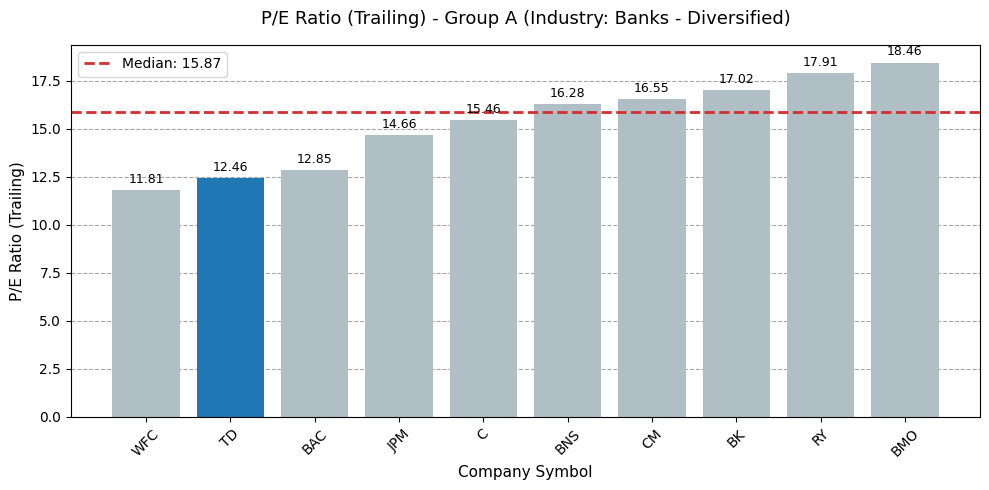

 COMPARISON OF MEDIAN RATINGS - Group A (Industry: Banks - Diversified):
   -> TD P/E Ratio (Trailing): 12.46
   -> Peer Median: 15.87
   -> Result: TD is located below (More cheaper than the median).

--------------------------------------------------------------------------------


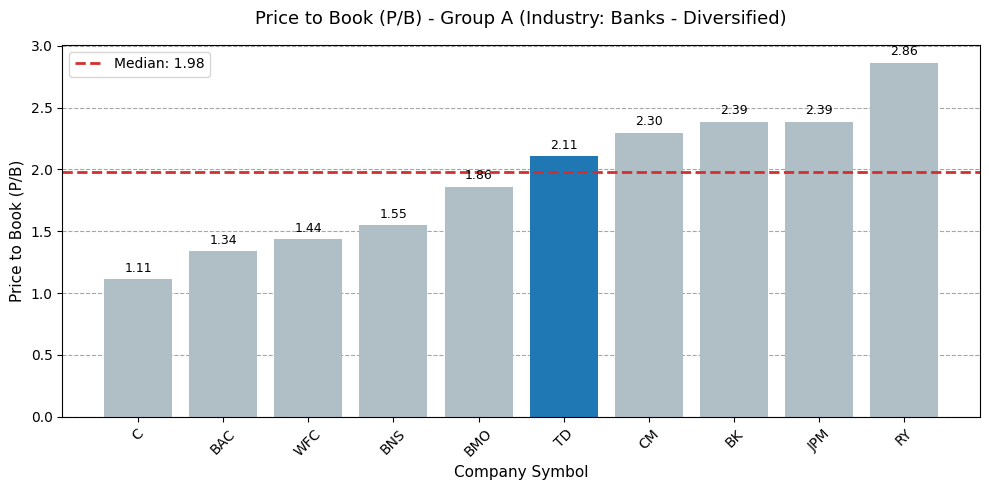

 COMPARISON OF MEDIAN RATINGS - Group A (Industry: Banks - Diversified):
   -> TD Price to Book (P/B): 2.11
   -> Peer Median: 1.98
   -> Result: TD is located Above (More expansive than the median).

--------------------------------------------------------------------------------


In [5]:


# ==========================================
# STEP 4: VALUATION ANALYSIS (GROUP A ONLY - ASCENDING)
# ==========================================

def plot_valuation_group_a(group_df, metric_name, group_title, target_symbol):
    
    """
    Create a bar chart for Group A only,
    sorted in ascending order as specified in the question.
    """
    
    # 1. MISSING VALUES RULE (Values <= 0 are already NaN from Step 1; here we remove the NaNs)
    plot_df = group_df.dropna(subset=[metric_name]).copy()
    
    if target_symbol not in plot_df['symbol'].values:
        print(f" {target_symbol} has no valid data for '{metric_name}' within the banking sector.")
        return
    
    # 2. CALCULATING THE MEDIAN AND RANK
    group_median = plot_df[metric_name].median()
    target_value = plot_df[plot_df['symbol'] == target_symbol][metric_name].values[0]
    
    position_text = "Above (More expansive than the median)" if target_value >= group_median else "below (More cheaper than the median)"
    
    # 3. ASCENDING ORDER (Explicitly requested: ascending=True)
    plot_df = plot_df.sort_values(by=metric_name, ascending=True)
    
    # 4. COLOURS (Blue for TD, Grey for the others)
    my_colors = ['#1f77b4' if sym == target_symbol else '#B0BEC5' for sym in plot_df['symbol']]
    
    # 5. CREATING THE CHART
    plt.figure(figsize=(10, 5))
    ax = plt.gca()
    
    # Background grid
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='--', alpha=0.7, color='gray')
    
    # Bar design
    bars = plt.bar(plot_df['symbol'], plot_df[metric_name], color=my_colors)
    
    # Median's line
    plt.axhline(group_median, color='#D32F2F', linestyle='--', linewidth=2, 
                label=f'Median: {group_median:.2f}')
    
    # Headings and formatting
    clean_metric_title = 'P/E Ratio (Trailing)' if metric_name == 'pe_trailing' else 'Price to Book (P/B)'
    plt.title(f"{clean_metric_title} - {group_title}", fontsize=13, pad=15)
    plt.ylabel(clean_metric_title, fontsize=11)
    plt.xlabel("Company Symbol", fontsize=11)
    plt.xticks(rotation=45)
    plt.legend(loc='upper left') # Messa a sinistra così non copre le barre alte a destra
    
    # Numbers above the bars
    for bar in bars:
        yval = bar.get_height()
        if yval > 0:
            ax.annotate(f"{yval:.2f}", 
                        (bar.get_x() + bar.get_width() / 2., yval), 
                        ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
        
    plt.tight_layout()
    plt.show()
    
    # Text for written translation
    print(f" COMPARISON OF MEDIAN RATINGS - {group_title}:")
    print(f"   -> {target_symbol} {clean_metric_title}: {target_value:.2f}")
    print(f"   -> Peer Median: {group_median:.2f}")
    print(f"   -> Result: {target_symbol} is located {position_text}.\n")
    print("-" * 80)

# ==========================================
# ESECUZIONE (SOLO GRUPPO A)
# ==========================================
selected_valuation_metrics = ['pe_trailing', 'price_to_book']


for metric in selected_valuation_metrics:
    plot_valuation_group_a(group_a, metric, f"Group A (Industry: {my_industry})", my_symbol)

### Written Interpretation: Valuation Metrics

Based on the analysis of Group A (Industry Peers), Toronto-Dominion Bank (TD) presents a compelling "value" profile when cross-referenced with its profitability metrics.

* **P/E Ratio (Trailing):** TD’s P/E ratio (12.46) is lower than the peer median (15.87). This indicates that the stock is currently trading at a discount compared to its direct competitors, as investors are paying less to acquire each dollar of TD's earnings. Recalling our findings in Step 3, this lower multiple does not stem from poor productivity; rather, it suggests the market is currently undervaluing a highly efficient and profitable company.

* **Price to Book (P/B):** Conversely, TD’s P/B ratio (2.11) is higher than the median (1.98), implying that the market prices TD's equity at a slight premium relative to its tangible assets. This is perfectly coherent with our profitability analysis: because TD generates superior returns on its equity (a higher ROE than its peers), investors are willing to pay a higher multiple to own that high-quality capital.